# Merged ATEM Inversion Results Plot

> This is notebook to review the inversion results generated by `tools/main_merged.py`.

## Workflow Overview

- Load merged inversion results (`*_inv_results_atem_full.pik`).
- Conduct binning process using `binning_normal(dx=50)`.
- Calculate active data ratio, misfit per iteration, and regularization metadata
- Interactive plotting function to show depth slice, difference map, L-curve

In [1]:
import dill
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
from matplotlib.colors import LogNorm
from ipywidgets import VBox, interactive_output, widgets
from rich import print
from scipy.spatial import cKDTree as KDTree
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
from types import SimpleNamespace
from cmcrameri import cm

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["figure.facecolor"] = "None"

In [2]:
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

print(f"Current Working Directory: {os.getcwd()}")

sys.path.append("tools")
from tools import binning

Current Working Directory: /Volumes/X31/01.Projects/atem

## 1. Load merged inversion restuls and binning configuration

In [3]:
areas = ["NW", "NE", "SE", "SW", "tielines"]
output_prefix = "merged"
dx = 50.0
istart_channel = 3
iend_channel = 25

criteria_rerr = 0.05
criteria_uncertainty = 0.05
bad_line_uncertainty = 0.30
floors_c = 0.05


def rebuild_merged_binned_frames(areas, dx=50.0):
    all_values = []
    all_values_std = []
    all_soundings = []

    times = None
    n_turns = None
    dheader = None
    picker = None

    for area in areas:
        tmp = binning(dx=dx, area=area)
        if times is None:
            times = tmp["times"]
            n_turns = tmp["n_turns"]
            dheader = tmp["dheader"]
            picker = tmp["picker"]

        all_values.extend(tmp["values"])
        all_values_std.extend(tmp["values_std"])
        all_soundings.extend(tmp["soundings"])

    if not all_values:
        raise ValueError("No binned data were reconstructed from the requested areas.")

    df_data_binned = pd.DataFrame(
        data=np.vstack(all_values),
        columns=["Line", "distance"] + picker[1:],
    )
    df_data_std_binned = pd.DataFrame(
        data=np.vstack(all_values_std),
        columns=["bheight"] + dheader,
    )

    for col in df_data_binned.columns:
        if col == "Line":
            df_data_binned[col] = df_data_binned[col].astype(str)
        else:
            df_data_binned[col] = pd.to_numeric(df_data_binned[col], errors="coerce")

    for col in df_data_std_binned.columns:
        df_data_std_binned[col] = pd.to_numeric(
            df_data_std_binned[col], errors="coerce"
        )

    return {
        "times": np.asarray(times, dtype=float),
        "soundings": [int(val) for val in all_soundings],
        "n_turns": float(n_turns),
        "dheader": list(dheader),
        "picker": list(picker),
        "df_data_binned": df_data_binned,
        "df_data_std_binned": df_data_std_binned,
    }

In [4]:
merged_data = rebuild_merged_binned_frames(areas=areas, dx=dx)
times = merged_data["times"]
soundings = merged_data["soundings"]
n_turns = merged_data["n_turns"]
dheader = merged_data["dheader"]
picker = merged_data["picker"]
df_data_binned = merged_data["df_data_binned"]
df_data_std_binned = merged_data["df_data_std_binned"]

result_path_1 = Path("./outputs/sharp/sharp_inv_atem_m0_10.pik")
result_path_2 = Path("./outputs/sharp/sharp_inv_atem_m0_100.pik")

with result_path_1.open("rb") as f:
    outDict1 = dill.load(f)

with result_path_2.open("rb") as f:
    outDict2 = dill.load(f)


In [5]:
iter_keys = sorted(outDict1.keys())
iterations = len(iter_keys)
first_key = iter_keys[0]

print(f"Areas: {areas}")
print(f"Iterations: {iterations}")
print(f"Binned soundings: {len(df_data_binned):,}")
print(f"Per-line sounding counts: {len(soundings):,} lines")
print(f"Stored keys at iteration {first_key}: {list(outDict1[first_key].keys())}")
print(f"m shape: {np.asarray(outDict1[first_key]['m']).shape}")
print(f"dpred shape: {np.asarray(outDict1[first_key]['dpred']).shape}")

Areas: ['NW', 'NE', 'SE', 'SW', 'tielines']

Iterations: 30

Binned soundings: 561,475

Per-line sounding counts: 513 lines

Stored keys at iteration 1: ['iter', 'beta', 'phi_d', 'phi_m', 'f', 'm', 'dpred', 'SparseSmallness.irls_threshold',
'SparseSmallness.norm', 'r LaterallyConstrainedSmoothness.irls_threshold', 'r LaterallyConstrainedSmoothness.norm',
'z LaterallyConstrainedSmoothness.irls_threshold', 'z LaterallyConstrainedSmoothness.norm']

m shape: (12352450,)

dpred shape: (12352450,)

In [6]:
iter_keys = sorted(outDict2.keys())
iterations = len(iter_keys)
first_key = iter_keys[0]

print(f"Areas: {areas}")
print(f"Iterations: {iterations}")
print(f"Binned soundings: {len(df_data_binned):,}")
print(f"Per-line sounding counts: {len(soundings):,} lines")
print(f"Stored keys at iteration {first_key}: {list(outDict2[first_key].keys())}")
print(f"m shape: {np.asarray(outDict2[first_key]['m']).shape}")
print(f"dpred shape: {np.asarray(outDict2[first_key]['dpred']).shape}")

Areas: ['NW', 'NE', 'SE', 'SW', 'tielines']

Iterations: 30

Binned soundings: 561,475

Per-line sounding counts: 513 lines

Stored keys at iteration 1: ['iter', 'beta', 'phi_d', 'phi_m', 'f', 'm', 'dpred', 'SparseSmallness.irls_threshold',
'SparseSmallness.norm', 'r LaterallyConstrainedSmoothness.irls_threshold', 'r LaterallyConstrainedSmoothness.norm',
'z LaterallyConstrainedSmoothness.irls_threshold', 'z LaterallyConstrainedSmoothness.norm']

m shape: (12352450,)

dpred shape: (12352450,)

In [7]:
soundings_path = Path("./outputs/sharp/sharp_soundings.json")
if soundings_path.exists():
    with soundings_path.open("r") as f:
        saved_soundings = [int(val) for val in json.load(f)]
    print(f"Saved soundings match reconstructed order: {saved_soundings == soundings}")
else:
    print(
        "No saved merged soundings JSON was found; using reconstructed ordering only."
    )

Saved soundings match reconstructed order: True

## 2. Uncertainty mask, Interpolated map for depth slice

In [8]:
data_ = df_data_binned[dheader].values.astype(float)
channel_id = np.tile(np.arange(data_.shape[1]), (data_.shape[0], 1))
data_rerr = (
    df_data_std_binned[dheader].values / np.abs(df_data_binned[dheader].values)
).astype(float)
cut_off = (data_rerr > criteria_rerr) * (channel_id >= 0)

floors = 5e-9 / (df_data_binned["TranPeak"].values * n_turns) * floors_c
dobs = df_data_binned[dheader].values.flatten().astype(float)
std = df_data_std_binned[dheader].values.flatten().astype(float)
dobs_std = np.abs(dobs) * criteria_uncertainty
dobs_std[std > dobs_std] = std[std > dobs_std]
dobs_std[cut_off.flatten()] = np.inf
dobs_std += np.repeat(floors, iend_channel - istart_channel)

active_data_count = int(dobs.shape[0] - cut_off.sum())
print(
    f"Active data percentage = {active_data_count:,}/{len(dobs):,} = {active_data_count / len(dobs) * 100:,.1f}%"
)

topography = df_data_binned[["x_wgs84", "y_wgs84", "dtm"]].values.astype(float)
source_heights = df_data_binned["bheight"].values.astype(float)
thickness = get_vertical_discretization(21, 2, 1.17)
hz = np.r_[thickness, thickness[-1]]
depth_edges = np.r_[0.0, np.cumsum(hz)]
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])

input_data_dict = {
    "topography": topography,
    "source_heights": source_heights,
    "thickness": thickness,
    "times": times,
}
inp = SimpleNamespace(**input_data_dict)

line_no = list(df_data_binned["Line"].astype(str).unique())
line_name_values = [str(val) for val in line_no]
n_sounding = len(df_data_binned)
n_layer = len(hz)
n_time = len(times)

model_size = np.asarray(outDict1[first_key]["m"], dtype=float).size
expected_model_size = n_sounding * n_layer
if model_size != expected_model_size:
    raise ValueError(f"Model size mismatch: {model_size} != {expected_model_size}")

observed_matrix = np.asarray(dobs, dtype=float).reshape((-1, n_time))
phi_d = np.array([outDict1[i]["phi_d"] for i in iter_keys], dtype=float)
phi_m = np.array([outDict1[i]["phi_m"] for i in iter_keys], dtype=float)
no_of_data_points = active_data_count
chi_squared = phi_d / no_of_data_points


def get_iteration_summary(outDict, i_iteration):
    iteration_dict = outDict[i_iteration]
    m_iter = np.asarray(iteration_dict["m"], dtype=float)
    dpred_iter = np.asarray(iteration_dict["dpred"], dtype=float).reshape((-1, n_time))
    rho_layers = (1.0 / np.exp(m_iter)).reshape((n_sounding, n_layer))
    return {
        "m": m_iter,
        "dpred": dpred_iter,
        "rho_layers": rho_layers,
        "phi_d": float(iteration_dict["phi_d"]),
        "phi_m": float(iteration_dict["phi_m"]),
    }


line_slices = {}
distance_by_line = {}
offset = 0
for line_name, count in zip(line_name_values, soundings):
    next_offset = offset + int(count)
    line_slice = slice(offset, next_offset)
    line_slices[str(line_name)] = line_slice
    distance_by_line[str(line_name)] = pd.to_numeric(
        df_data_binned.iloc[line_slice]["distance"],
        errors="coerce",
    ).to_numpy(dtype=float)
    offset = next_offset

if offset != n_sounding:
    raise ValueError(f"Sounding count mismatch: {offset} != {n_sounding}")

map_dx = 100.0
map_dy = 100.0
x_pad = 1000.0
y_pad = 1000.0
k_nearest_points = 100
max_distance = 1000.0
idw_power = 0.0

xy_model = inp.topography[:, :2]
xmin = np.nanmin(xy_model[:, 0]) - x_pad
xmax = np.nanmax(xy_model[:, 0]) + x_pad
ymin = np.nanmin(xy_model[:, 1]) - y_pad
ymax = np.nanmax(xy_model[:, 1]) + y_pad

nx = int(np.floor((xmax - xmin) / map_dx)) + 1
ny = int(np.floor((ymax - ymin) / map_dy)) + 1
x_map = np.arange(nx) * map_dx + xmin
y_map = np.arange(ny) * map_dy + ymin
X_map, Y_map = np.meshgrid(x_map, y_map)

map_tree = KDTree(xy_model)
k_idw = min(int(k_nearest_points), len(xy_model))
distances_idw, indices_idw = map_tree.query(
    np.c_[X_map.ravel(), Y_map.ravel()], k=k_idw
)
if k_idw == 1:
    distances_idw = distances_idw[:, None]
    indices_idw = indices_idw[:, None]

idw_epsilon = min(map_dx, map_dy)
idw_weights = 1.0 / ((distances_idw + idw_epsilon) ** idw_power)
nearest_distance, _ = map_tree.query(np.c_[X_map.ravel(), Y_map.ravel()], k=1)
mask_outside_data = nearest_distance > max_distance


def interpolate_to_map(values):
    values = np.asarray(values, dtype=float)
    values_grid = np.sum(idw_weights * values[indices_idw], axis=1) / np.sum(
        idw_weights, axis=1
    )
    values_grid[mask_outside_data] = np.nan
    return values_grid.reshape(X_map.shape)


print(f"n_sounding={n_sounding:,}, n_layer={n_layer}, n_time={n_time}")
print(f"Map grid: {X_map.shape} | k_idw={k_idw}")
print(f"chi-squared normalization uses active data count: {no_of_data_points:,}")

Active data percentage = 10,717,706/12,352,450 = 86.8%

>> Depth from the surface to the base of the bottom layer is 306.3m


n_sounding=561,475, n_layer=22, n_time=22

Map grid: (2054, 1511) | k_idw=100

chi-squared normalization uses active data count: 10,717,706

## 3. Interactive depth slice 

In [9]:
def plot_combined_map_and_line(i_iteration, line_name, i_depth, outDict):
    summary = get_iteration_summary(outDict, i_iteration)
    rho_layers = summary["rho_layers"]
    dpred_matrix = summary["dpred"]

    values_grid = interpolate_to_map(rho_layers[:, i_depth])
    line_slice = line_slices[str(line_name)]
    selected_line = df_data_binned.iloc[line_slice].copy()
    if selected_line.empty:
        raise ValueError(f"No data found for line {line_name}")

    distances = distance_by_line[str(line_name)]
    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    out = ax1.pcolormesh(
        x_map,
        y_map,
        values_grid,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    # ax1.plot(xy_model[:, 0], xy_model[:, 1], "k,", alpha=0.12)
    ax1.plot(
        selected_line["x_wgs84"],
        selected_line["y_wgs84"],
        color="white",
        linewidth=2.0,
    )
    ax1.plot(
        selected_line["x_wgs84"],
        selected_line["y_wgs84"],
        color="black",
        linewidth=0.8,
    )
    ax1.scatter(
        selected_line["x_wgs84"].iloc[0],
        selected_line["y_wgs84"].iloc[0],
        s=30,
        color="white",
        edgecolor="black",
        zorder=5,
    )
    cb = plt.colorbar(out, ax=ax1, orientation="vertical")
    cb.set_label("Resistivity (ohm-m)")
    ax1.set_xlabel("x_wgs84")
    ax1.set_ylabel("y_wgs84")
    ax1.set_aspect(1)
    ax1.set_title(
        f"Iteration {i_iteration}, Line {line_name}, Depth {depth_centers[i_depth]:.1f} m"
    )
    ax1.grid(True, alpha=0.15)

    dpred_line = -np.asarray(dpred_matrix[line_slice, :], dtype=float)[sort_idx, :]
    dobs_line = -np.asarray(observed_matrix[line_slice, :], dtype=float)[sort_idx, :]
    for i_time in range(n_time):
        ax2.plot(
            distances_sorted,
            dpred_line[:, i_time],
            "-",
            linewidth=1.0,
            alpha=0.7,
            label=f"T{i_time}" if i_time < 6 else None,
        )
        ax2.plot(
            distances_sorted,
            dobs_line[:, i_time],
            "k--",
            linewidth=0.8,
            alpha=0.35,
        )

    ax2.set_yscale("log")
    ax2.set_xlabel("Distance along line (m)")
    ax2.set_ylabel("|dB/dt| (V/A/m²)")
    ax2.grid(False)
    ax2.set_title(f"Iteration {i_iteration}, Line {line_name}")
    ax2.legend(ncol=2, fontsize=8, loc="best")

    plt.tight_layout()
    plt.show()


iter_depth_slider = widgets.IntSlider(
    min=min(iter_keys),
    max=max(iter_keys),
    step=1,
    value=min(iter_keys),
    description="Iteration:",
    continuous_update=False,
)
line_slider = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
)
depth_slider = widgets.SelectionSlider(
    options=[(f"{i}: {depth_centers[i]:.1f} m", i) for i in range(n_layer)],
    value=0,
    description="Depth:",
    continuous_update=False,
)

combined_output = interactive_output(
    plot_combined_map_and_line,
    {
        "i_iteration": iter_depth_slider,
        "line_name": line_slider,
        "i_depth": depth_slider,
        "outDict": widgets.fixed(outDict2)
    },
)

VBox([iter_depth_slider, line_slider, depth_slider, combined_output])

## 5. Interactive XZ cross section 

In [10]:
def _compute_cell_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5])

    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - (mids[0] - values[0])
    right = values[-1] + (values[-1] - mids[-1])
    return np.r_[left, mids, right]


def _moving_average_nan_1d(arr, window):
    if window <= 1:
        return arr
    kernel = np.ones(window, dtype=float)
    valid = np.isfinite(arr).astype(float)
    filled = np.where(np.isfinite(arr), arr, 0.0)
    num = np.convolve(filled, kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    out = np.full_like(arr, np.nan, dtype=float)
    mask = den > 0
    out[mask] = num[mask] / den[mask]
    return out


def _smooth_section_2d(section, window_x=5, window_z=1):
    smoothed = section.copy().astype(float)
    if window_x > 1:
        for i in range(smoothed.shape[0]):
            smoothed[i, :] = _moving_average_nan_1d(smoothed[i, :], window_x)
    if window_z > 1:
        for j in range(smoothed.shape[1]):
            smoothed[:, j] = _moving_average_nan_1d(smoothed[:, j], window_z)
    return smoothed


def plot_line_xz_section(
    i_iteration,
    line_name,
    outDict,
    apply_smoothing=False,
    smooth_x=5,
    smooth_z=1,
):
    line_slice = line_slices[str(line_name)]
    summary = get_iteration_summary(outDict, i_iteration)
    rho_layers = summary["rho_layers"]
    dpred_matrix = summary["dpred"]

    line_rho = rho_layers[line_slice, :]
    line_df = df_data_binned.iloc[line_slice]

    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
        dtype=float
    )
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)

    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho_sorted = np.asarray(line_rho[sort_idx, :], dtype=float)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    # fig, (ax, ax_data, ax_loc) = plt.subplots(
    #     1,
    #     3,
    #     figsize=(25, 6),
    #     gridspec_kw={"width_ratios": [6, 3, 3]},
    # )
    fig, (ax, ax_loc) = plt.subplots(
        1,
        2,
        figsize=(20, 5),
        gridspec_kw={"width_ratios": [6, 1]},
    )

    section = line_rho_sorted.T
    if apply_smoothing:
        section = _smooth_section_2d(
            section, window_x=int(smooth_x), window_z=int(smooth_z)
        )

    pcm = ax.pcolormesh(
        X_edges,
        Z_edges,
        section,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    cbar = plt.colorbar(
        pcm,
        ax=ax,
        orientation="horizontal",
        pad=0.14,
        fraction=0.08,
    )
    ax.plot(X_edges[0,:], Z_edges[0,:] - 50, "k.", markersize=0.3)
    cbar.set_label("Resistivity (ohm-m)")

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax.set_xlim(x_min, x_max)
    ax.set_xlabel("Distance along line (m)")
    ax.set_ylabel("Elevation (m)")
    smooth_tag = (
        f" | smooth x={int(smooth_x)}, z={int(smooth_z)}" if apply_smoothing else ""
    )
    ax.set_title(
        f"Terrain-following XZ Section | Iteration {i_iteration}, Line {line_name}{smooth_tag}"
    )
    ax.grid(False)

    x_all = pd.to_numeric(df_data_binned["x_wgs84"], errors="coerce").to_numpy(
        dtype=float
    )
    y_all = pd.to_numeric(df_data_binned["y_wgs84"], errors="coerce").to_numpy(
        dtype=float
    )
    x_line = x_all[line_slice][sort_idx]
    y_line = y_all[line_slice][sort_idx]

    all_mask = np.isfinite(x_all) & np.isfinite(y_all)
    line_mask = np.isfinite(x_line) & np.isfinite(y_line)

    if np.any(all_mask):
        ax_loc.scatter(
            x_all[all_mask],
            y_all[all_mask],
            s=2,
            c="lightgray",
            edgecolors="none",
            alpha=0.7,
        )

    if np.any(line_mask):
        ax_loc.plot(
            x_line[line_mask],
            y_line[line_mask],
            color="crimson",
            linewidth=1.6,
            zorder=3,
        )
        ax_loc.scatter(
            x_line[line_mask][0],
            y_line[line_mask][0],
            s=26,
            c="white",
            edgecolors="black",
            zorder=4,
        )
    else:
        ax_loc.text(
            0.5,
            0.5,
            "No valid XY",
            ha="center",
            va="center",
            transform=ax_loc.transAxes,
        )

    ax_loc.set_aspect(1)
    ax_loc.set_title(f"Locator\nLine {line_name}")
    ax_loc.set_xlabel("x_wgs84")
    ax_loc.set_ylabel("y_wgs84")
    ax_loc.grid(False)

    plt.tight_layout()
    plt.show()


iter_slider_xz = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys],
    value=iter_keys[0],
    description="Iteration:",
    continuous_update=False,
)

line_slider_xz = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
    continuous_update=False,
)

smooth_toggle = widgets.Checkbox(
    value=False,
    description="Apply smoothing",
)

smooth_x_slider = widgets.IntSlider(
    value=5,
    min=1,
    max=31,
    step=2,
    description="Smooth X:",
    continuous_update=False,
)

smooth_z_slider = widgets.IntSlider(
    value=1,
    min=1,
    max=9,
    step=2,
    description="Smooth Z:",
    continuous_update=False,
)

xz_output = interactive_output(
    plot_line_xz_section,
    {
        "i_iteration": iter_slider_xz,
        "line_name": line_slider_xz,
        "apply_smoothing": smooth_toggle,
        "smooth_x": smooth_x_slider,
        "smooth_z": smooth_z_slider,
        "outDict": widgets.fixed(outDict2)
    },
)

VBox(
    [
        iter_slider_xz,
        line_slider_xz,
        smooth_toggle,
        smooth_x_slider,
        smooth_z_slider,
        xz_output,
    ]
)

In [11]:
selected_iter1:int = 20
selected_iter2:int = 20

summary1 = get_iteration_summary(outDict1, selected_iter1)
summary2 = get_iteration_summary(outDict2, selected_iter1)
rho_layers1 = summary1["rho_layers"]
rho_layers2 = summary2["rho_layers"]
del summary1, summary2


## 6. Gradient criteria, \(\chi^2\), L-curve

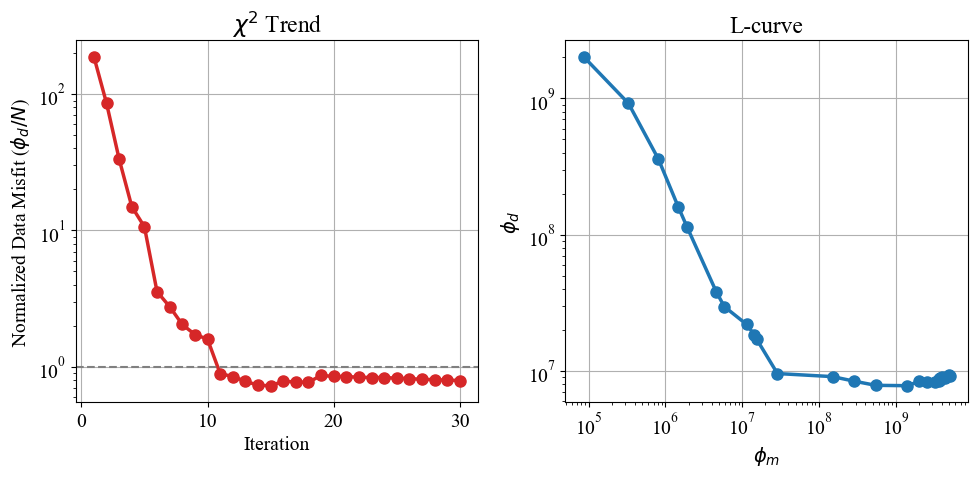

In [12]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(
    iter_keys, chi_squared, marker="o", color="tab:red", linewidth=2.5, markersize=8
)
plt.axhline(
    y=1.0, color="gray", linestyle="--", linewidth=1.5, label="Target $\\chi^2$"
)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Normalized Data Misfit ($\\phi_d / N$)")
plt.title("$\\chi^2$ Trend")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(phi_m, phi_d, marker="o", color="tab:blue", linewidth=2.5, markersize=8)
plt.xscale("log")
plt.yscale("log")
plt.title("L-curve")
plt.xlabel("$\\phi_m$")
plt.ylabel("$\\phi_d$")
plt.grid()
plt.tight_layout()
plt.show()

# output_dir = Path("./outputs/merged_inversion_results")
# output_dir.mkdir(parents=True, exist_ok=True)

# summary_frame = pd.DataFrame(
#     {
#         "iteration": iter_keys,
#         "phi_d": phi_d,
#         "phi_m": phi_m,
#         "chi_squared": chi_squared,
#     }
# )

In [13]:
from cmcrameri import cm

def scaler(x):
    x = np.asarray(x, dtype=float)
    if np.all(np.isnan(x)):
        return x
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    if x_max == x_min:
        return np.zeros_like(x)
    return (x - x_min) / (x_max - x_min)

def cal_index(m1,m2):
    m0_1 = 10
    m0_2 = 100
    return (m2 - m1)/(m0_2 - m0_1)

def plot_line_xz_section(line_name):
    line_slice = line_slices[str(line_name)]
    line_df = df_data_binned.iloc[line_slice]
    line_rho1 = rho_layers1[line_slice, :]
    line_rho2 = rho_layers2[line_slice, :]
    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
        dtype=float
    )
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)
    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho1_sorted = np.asarray(line_rho1[sort_idx, :], dtype=float)
    line_rho2_sorted = np.asarray(line_rho2[sort_idx, :], dtype=float)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    section1 = line_rho1_sorted.T
    section2 = line_rho2_sorted.T
    cal_ind = cal_index(section1, section2)
    cal_mask = cal_ind > 0.1

    cent_x = 0.5 * (X_edges[1:,1:] + X_edges[1:,:-1])
    cent_z = 0.5 * (Z_edges[1:,1:] + Z_edges[:-1,1:])

    doi_depth = []
    for i in range(cal_ind.shape[1]):
        if ~cal_mask[:,i].sum() != 0:
            tmp = cent_z[~cal_mask[:,i]]
            doi_depth.append(
                np.min(tmp[:,i] if tmp.size > 0 else np.max(cent_z[:,i]))
                )

    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        figsize=(20, 10),
    )

    ax1.pcolormesh(
        X_edges,
        Z_edges,
        section1,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )

    ax2.pcolormesh(
        X_edges,
        Z_edges,
        section2,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax1.set_xlim(x_min, x_max)
    ax1.set_xlabel("Distance along line (m)")
    ax1.set_ylabel("Elevation (m)")
    ax1.set_title("m0: 10 ohmm")
    ax1.grid(False)


    ax2.set_xlim(x_min, x_max)
    ax2.set_xlabel("Distance along line (m)")
    ax2.set_ylabel("Elevation (m)")
    ax2.set_title("m0: 100 ohmm")
    ax2.grid(False)
    
    # cal_ind[cal_mask] = np.nan
    pcm3 = ax3.pcolormesh(
        X_edges,
        Z_edges,
        cal_ind,
        cmap=cm.tofino,
        shading="auto",
        vmin=0,
        vmax=1
    )
    plt.colorbar(
        pcm3,
        orientation="horizontal",
        pad=0.14,
        fraction=0.08,
    )
    plt.plot(cent_x[0,:], doi_depth, "r-", linewidth=1.5, label="Depth of cal index > 0.1")
    plt.tight_layout()

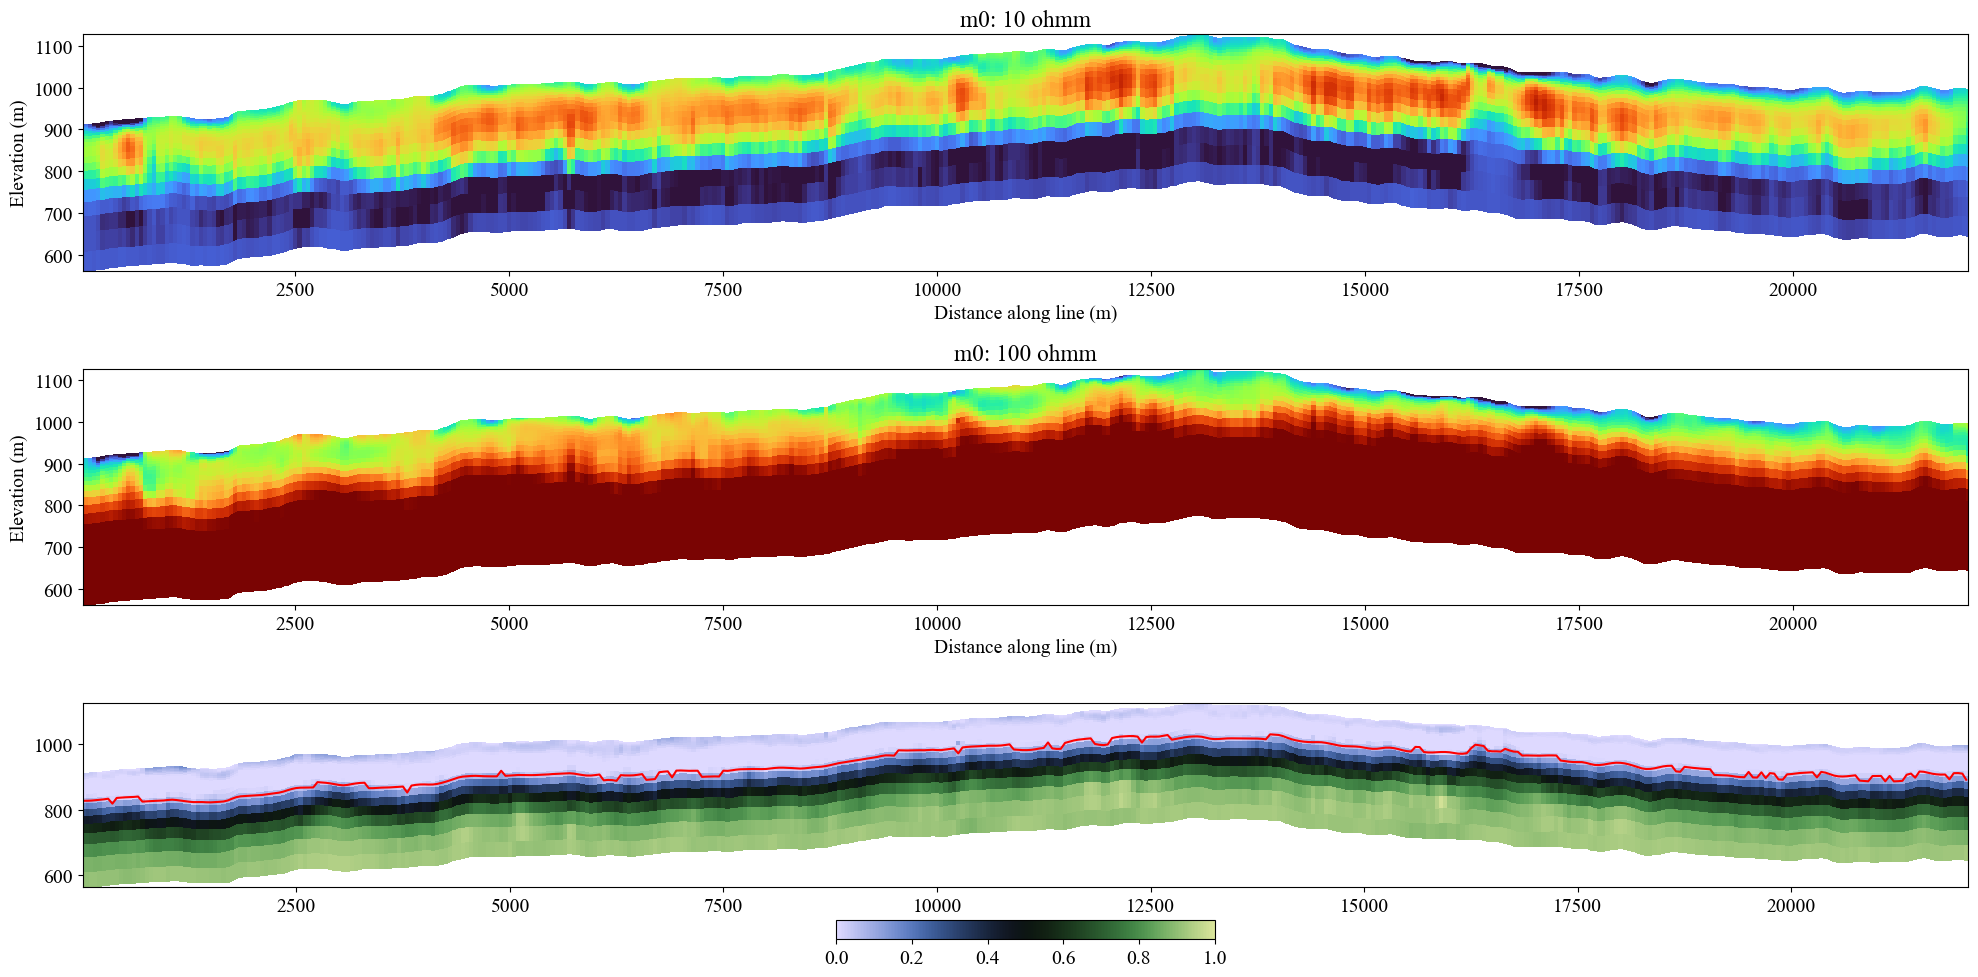

In [14]:
plot_line_xz_section(line_name=line_name_values[0])

line_slider_xz = widgets.SelectionSlider(
    options=line_name_values,
    value=line_name_values[0],
    description="Line:",
    continuous_update=False,
)

xz_output = interactive_output(
    plot_line_xz_section,
    {
        "line_name": line_slider_xz,
    },
)

VBox(
    [
        line_slider_xz,
        xz_output,
    ]
)

- Save Depth of investigation

In [15]:
def save_doi():
    data_list = []
    for line_name in line_name_values:
        line_slice = line_slices[str(line_name)]
        line_df = df_data_binned.iloc[line_slice]
        x = line_df["x_wgs84"].values
        y = line_df["y_wgs84"].values

        line_rho1 = rho_layers1[line_slice, :]
        line_rho2 = rho_layers2[line_slice, :]
        distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
            dtype=float
        )
        dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)
        sort_idx = np.argsort(distances)
        dtm_sorted = dtm_line[sort_idx]
        line_rho1_sorted = np.asarray(line_rho1[sort_idx, :], dtype=float)
        line_rho2_sorted = np.asarray(line_rho2[sort_idx, :], dtype=float)

        dtm_edges = _compute_cell_edges(dtm_sorted)
        Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

        section1 = line_rho1_sorted.T
        section2 = line_rho2_sorted.T
        cal_ind = cal_index(section1, section2)
        cal_mask = cal_ind > 0.2

        cent_z = 0.5 * (Z_edges[1:,1:] + Z_edges[:-1,1:])

        doi_depth = []
        doi_index = []
        for i in range(cal_ind.shape[1]):
            if ~cal_mask[:,i].sum() != 0:
                tmp = cent_z[~cal_mask[:,i]]
                doi_depth.append(
                    np.min(tmp[:,i] if tmp.size > 0 else np.max(cent_z[:,i]))
                    )
                doi_index.append(
                    np.argmin(tmp[:,i] if tmp.size > 0 else np.max(cent_z[:,i])
                ))
        doi_data = np.column_stack(
            (
                x,y,doi_depth,doi_index
            )
        )
        data_list.append(doi_data)
    data_arr = np.vstack(data_list)
    np.savetxt(
        "./outputs/sharp/doi_depth.txt",
        data_arr,
        delimiter="\t",
        header="x_wgs84\ty_wgs84\tdoi_depth\tdoi_index"
    )


In [16]:
save_doi()